In [78]:
from brian2 import *
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

prefs.codegen.target = 'numpy'
seed(67)
start_scope()

In [79]:
DURATION        = 500 * ms
defaultclock.dt = 0.1 * ms

N_GC, N_MC, N_BC = 1600, 50, 10

In [80]:
# ─── Leaky integrate-and-fire model ──────────────────────────────────────────
# tau * dv/dt = -(v - v_rest) + R*I
# Physiological LIF: tau=20ms, R=100 MOhm, threshold=-50mV, reset=-70mV
lif_eqs = '''
dv/dt = (-(v - v_rest) + R_m * (I_ext + I_syn)) / tau_m : volt
I_syn : amp
I_ext : amp
tau_m  : second
R_m    : ohm
v_rest : volt
'''

LIF_params = dict(
    tau_m  = 20  * ms,
    R_m    = 100 * Mohm,
    v_rest = -70 * mV,
)

V_thresh = -50 * mV
V_reset  = -70 * mV
V_refrac =  3  * ms

def make_group(N, I_mean_pA, I_sigma_pA):
    G = NeuronGroup(N, lif_eqs,
                    threshold = 'v > -50*mV',
                    reset     = 'v = -70*mV',
                    refractory= V_refrac,
                    method    = 'euler')
    G.v     = '-70*mV + 5*mV*randn()'
    G.I_syn = 0 * pA
    G.set_states(LIF_params)
    G.I_ext = f'({I_mean_pA} + {I_sigma_pA}*randn()) * pA'
    return G

# ─── Synapses ─────────────────────────────────────────────────────────────────
def exc_syn(src, tgt, w_pA, p, delay=1*ms):
    S = Synapses(src, tgt,
                 on_pre='I_syn_post += w_pA * pA',
                 namespace={'w_pA': w_pA},
                 delay=delay)
    S.connect(p=p)
    return S

def inh_syn(src, tgt, w_pA, p, delay=1*ms):
    S = Synapses(src, tgt,
                 on_pre='I_syn_post -= w_pA * pA',
                 namespace={'w_pA': w_pA},
                 delay=delay)
    S.connect(p=p)
    return S



lif_eqs = '''
dv/dt    = (-(v - v_rest) + R_m * (I_ext + I_syn)) / tau_m : volt
dI_syn/dt = -I_syn / tau_syn : amp
I_ext  : amp
tau_m  : second
tau_syn: second
R_m    : ohm
v_rest : volt
'''

LIF_params = dict(
    tau_m   = 20  * ms,
    tau_syn =  5  * ms,
    R_m     = 100 * Mohm,
    v_rest  = -70 * mV,
)

def make_group(N, I_mean_pA, I_sigma_pA):
    G = NeuronGroup(N, lif_eqs,
                    threshold  = 'v > -50*mV',
                    reset      = 'v = -70*mV',
                    refractory = 3 * ms,
                    method     = 'euler')
    G.v      = '-70*mV + 5*mV*randn()'
    G.I_syn  = 0 * pA
    G.set_states(LIF_params)
    G.I_ext  = f'({I_mean_pA} + {I_sigma_pA} * randn()) * pA'
    return G

def exc_syn(src, tgt, w_pA, p, delay=1*ms):
    S = Synapses(src, tgt,
                 on_pre='I_syn_post += w_pA * pA',
                 namespace={'w_pA': w_pA},
                 delay=delay)
    S.connect(p=p)
    return S

def inh_syn(src, tgt, w_pA, p, delay=1*ms):
    S = Synapses(src, tgt,
                 on_pre='I_syn_post -= w_pA * pA',
                 namespace={'w_pA': w_pA},
                 delay=delay)
    S.connect(p=p)
    return S

In [81]:
# SCENARIO A — HEALTHY

start_scope()
seed(42)
defaultclock.dt = 0.1 * ms

# Healthy groups
GC_h = make_group(N_GC, I_mean_pA=200, I_sigma_pA=50)  # push GCs just over threshold
MC_h = make_group(N_MC, I_mean_pA=220, I_sigma_pA=40)
BC_h = make_group(N_BC, I_mean_pA=120, I_sigma_pA=30)

# Healthy synapses
S_GC_MC = exc_syn(GC_h, MC_h, w_pA=100, p=0.5)
S_MC_BC = exc_syn(MC_h, BC_h, w_pA=120, p=0.6)
S_BC_GC = inh_syn(BC_h, GC_h, w_pA=50,  p=0.5)   

M_GC_h = SpikeMonitor(GC_h)
M_BC_h = SpikeMonitor(BC_h)
M_MC_h = SpikeMonitor(MC_h)

run(DURATION, report='text')

rates_h_GC = M_GC_h.count / (DURATION / second)
rates_h_BC = M_BC_h.count / (DURATION / second)
rates_h_MC = M_MC_h.count / (DURATION / second)

Starting simulation at t=0. s for a duration of 0.5 s
0.5 s (100%) simulated in 1s


In [82]:
# ══════════════════════════════════════════════════════════════════════════════
# SCENARIO B — EPILEPTIC
# Identical GC drive; MC destroyed; BC present but silent
# ══════════════════════════════════════════════════════════════════════════════
start_scope()
seed(42)
defaultclock.dt = 0.1 * ms

GC_e = make_group(N_GC, I_mean_pA=180, I_sigma_pA=50)
BC_e = make_group(N_BC, I_mean_pA=50,  I_sigma_pA=10)  

S_BC_GC_e = inh_syn(BC_e, GC_e, w_pA=40, p=0.5)  # intact 

M_GC_e = SpikeMonitor(GC_e)
M_BC_e = SpikeMonitor(BC_e)

run(DURATION, report='text')

rates_e_GC = M_GC_e.count / (DURATION / second)
rates_e_BC = M_BC_e.count / (DURATION / second)


Starting simulation at t=0. s for a duration of 0.5 s
0.5 s (100%) simulated in 1s


In [83]:
print("\n══ Summary ══")
print(f"Healthy   GC  mean rate : {rates_h_GC.mean():.1f} Hz")
print(f"Healthy   BC  mean rate : {rates_h_BC.mean():.1f} Hz")
print(f"Healthy   MC  mean rate : {rates_h_MC.mean():.1f} Hz")
print(f"Epileptic GC  mean rate : {rates_e_GC.mean():.1f} Hz")
print(f"Epileptic BC  mean rate : {rates_e_BC.mean():.1f} Hz")
print(f"GC rate fold-increase   : {rates_e_GC.mean() / max(rates_h_GC.mean(), 0.01):.1f}×")


══ Summary ══
Healthy   GC  mean rate : 0.1 Hz
Healthy   BC  mean rate : 152.4 Hz
Healthy   MC  mean rate : 36.1 Hz
Epileptic GC  mean rate : 8.1 Hz
Epileptic BC  mean rate : 0.0 Hz
GC rate fold-increase   : 61.1×


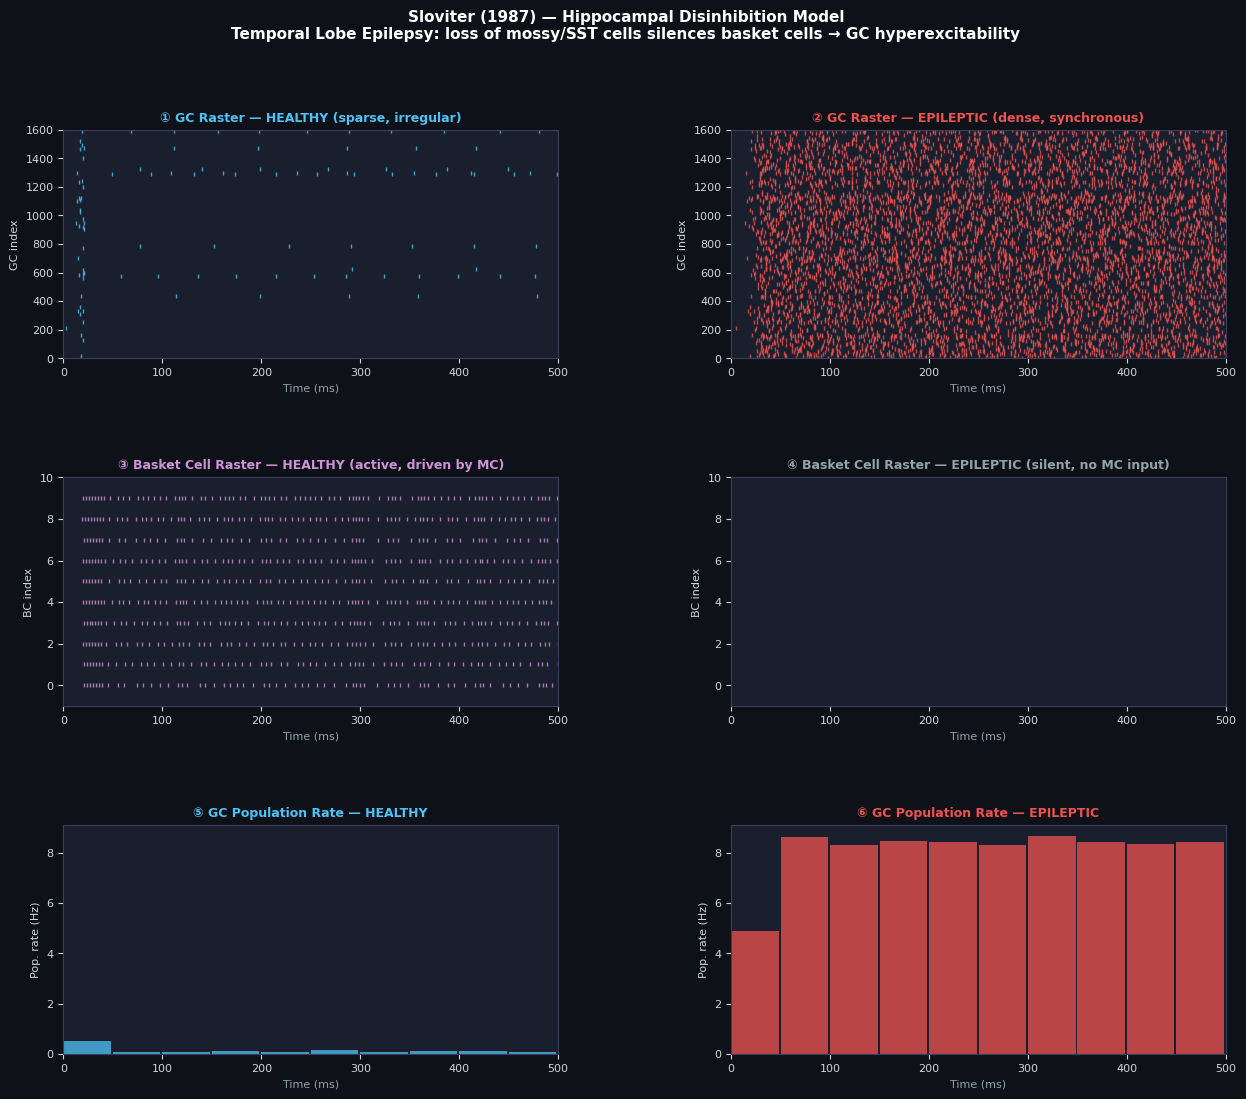

In [84]:
# ─── Plotting ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 12))
fig.patch.set_facecolor('#0e1117')
gs  = gridspec.GridSpec(3, 2, hspace=0.52, wspace=0.35)

BLUE = '#4fc3f7'; RED  = '#ef5350'
PURP = '#ce93d8'; GRAY = '#90a4ae'
AXCOL = '#1a1f2e'

def style_ax(ax, title, color):
    ax.set_facecolor(AXCOL)
    ax.tick_params(colors='#cfd8dc', labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#3a3f5e')
    ax.set_title(title, color=color, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel("Time (ms)", color='#90a4ae', fontsize=8)

t0, t1 = 0, DURATION / ms

# Row 0 — GC rasters
ax00 = fig.add_subplot(gs[0, 0])
ax00.plot(M_GC_h.t/ms, M_GC_h.i, '|', ms=3, color=BLUE, alpha=0.8)
ax00.set_xlim(t0, t1); ax00.set_ylim(-1, N_GC)
ax00.set_ylabel("GC index", color='#cfd8dc', fontsize=8)
style_ax(ax00, "① GC Raster — HEALTHY (sparse, irregular)", BLUE)

ax01 = fig.add_subplot(gs[0, 1])
ax01.plot(M_GC_e.t/ms, M_GC_e.i, '|', ms=3, color=RED, alpha=0.8)
ax01.set_xlim(t0, t1); ax01.set_ylim(-1, N_GC)
ax01.set_ylabel("GC index", color='#cfd8dc', fontsize=8)
style_ax(ax01, "② GC Raster — EPILEPTIC (dense, synchronous)", RED)

# Row 1 — BC rasters
ax10 = fig.add_subplot(gs[1, 0])
ax10.plot(M_BC_h.t/ms, M_BC_h.i, '|', ms=3, color=PURP, alpha=0.8)
ax10.set_xlim(t0, t1); ax10.set_ylim(-1, N_BC)
ax10.set_ylabel("BC index", color='#cfd8dc', fontsize=8)
style_ax(ax10, "③ Basket Cell Raster — HEALTHY (active, driven by MC)", PURP)

ax11 = fig.add_subplot(gs[1, 1])
ax11.plot(M_BC_e.t/ms, M_BC_e.i, '|', ms=3, color=GRAY, alpha=0.6)
ax11.set_xlim(t0, t1); ax11.set_ylim(-1, N_BC)
ax11.set_ylabel("BC index", color='#cfd8dc', fontsize=8)
style_ax(ax11, "④ Basket Cell Raster — EPILEPTIC (silent, no MC input)", GRAY)

# Row 2 — GC population rates
bins = np.arange(0, DURATION/ms + 50, 50)

ax20 = fig.add_subplot(gs[2, 0])
cnt_h, edges = np.histogram(M_GC_h.t/ms, bins=bins)
rate_h = cnt_h / (N_GC * 50e-3)
ax20.bar(edges[:-1], rate_h, width=48, color=BLUE, alpha=0.75, align='edge')
ax20.set_xlim(t0, t1)
ax20.set_ylabel("Pop. rate (Hz)", color='#cfd8dc', fontsize=8)
style_ax(ax20, "⑤ GC Population Rate — HEALTHY", BLUE)

ax21 = fig.add_subplot(gs[2, 1])
cnt_e, edges = np.histogram(M_GC_e.t/ms, bins=bins)
rate_e = cnt_e / (N_GC * 50e-3)
ax21.bar(edges[:-1], rate_e, width=48, color=RED, alpha=0.75, align='edge')
ax21.set_xlim(t0, t1)
ax21.set_ylabel("Pop. rate (Hz)", color='#cfd8dc', fontsize=8)
style_ax(ax21, "⑥ GC Population Rate — EPILEPTIC", RED)

ymax = max(ax20.get_ylim()[1], ax21.get_ylim()[1])
ax20.set_ylim(0, ymax); ax21.set_ylim(0, ymax)

fig.suptitle(
    "Sloviter (1987) — Hippocampal Disinhibition Model\n"
    "Temporal Lobe Epilepsy: loss of mossy/SST cells silences basket cells → GC hyperexcitability",
    color='white', fontsize=11, fontweight='bold', y=0.98
)

plt.savefig("sloviter_model.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()